<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/explainable_techniques_ii/02_explainability_california_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Techniques II: California Housing (PDP, ICE, ALE)

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Housing Price Prediction  
**Assigned Task:** Explainable Techniques II (PDP, ICE, ALE)  
**Dataset:** [California Housing Dataset (Cleaned)](https://raw.githubusercontent.com/ericiortega/aipi590-xai-fall2025/main/data/processed/california_housing_clean.csv)  
**Deadline:** Mon Sep 29, 2025 – 11:30 AM  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025/tree/main/assignments/explainable_techniques_ii)  


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (10, 4.5), "figure.dpi": 130})# improving how charts appear in the notebook; goal is to assist when TA's grade

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay



california_data = "https://raw.githubusercontent.com/ericiortega/aipi590-xai-fall2025/main/data/processed/california_housing_clean.csv"
df = pd.read_csv(california_data)

print(df.shape)
df.head()


(20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,452600.0,False,False,True,False
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,358500.0,False,False,True,False
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,352100.0,False,False,True,False
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,341300.0,False,False,True,False
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,342200.0,False,False,True,False


## Train/test split and incorporating the baseline model (random forest)

In [ ]:
target = "median_house_value"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
r2  = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print(f"Random Forest(300) — R2={r2:.3f}, mean abs error=${mae:,.0f} | train={len(X_train)}, test={len(X_test)} | target={target}")


RF(300) — R²=0.818, MAE=$31,473 | train=16512, test=4128 | target=median_house_value


> ### Baseline Model Results & Next Steps  
>  
> I trained a Random Forest Regressor with 300 trees on the California Housing dataset to predict median_house_value.  
>  
> - R² Score: 0.818 shows that the model explains about 82 percent of the variance in house prices.  
> - MAE (Mean Absolute Error) is about 31,473 dollars which means that on average, predictions are off by about 31K.  
>  
> Given that house values in this dataset range from tens of thousands to over 500K, this error is reasonable. Thus, this shows that random Forest is a strong baseline model for this prediction task.  
>  
> To better understand how this random forest model is making predictions, I will move to interpretability using PDP, ICE, and ALE.  
>  
> - PDP, or Partial Dependence Plot, shows how predictions change as one feature varies while averaging over other features. This gives a global sense of direction or shape but can be misleading when features are correlated.  
> - ICE, or Individual Conditional Expectation, shows one curve per instance and reveals heterogeneity and potential interactions. It is more detailed than PDP but still assumes other features are fixed.  
> - ALE, or Accumulated Local Effects, computes local effects within bins and accumulates them along the feature range. It is more robust when features are correlated, though the choice of bins affects smoothness.  
>  
> My next steps in this notebook are:  
> 1. Run a correlation and permutation analysis to check for relationships among features.  
> 2. Generate PDP plots with concise explanations.  
> 3. Generate ICE plots to reveal heterogeneity across instances.  
> 4. Generate ALE plots to confirm effects under correlation.  
> 5. Summarize key findings.

In [ ]:
# numeric features for PDP, ICE, and ALE
numeric_cols = X.select_dtypes(include=["float64","int64"]).columns

features_to_explain = [
    f for f in [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "latitude",
        "longitude",
    ] if f in numeric_cols
]


## Correlation & Permutation

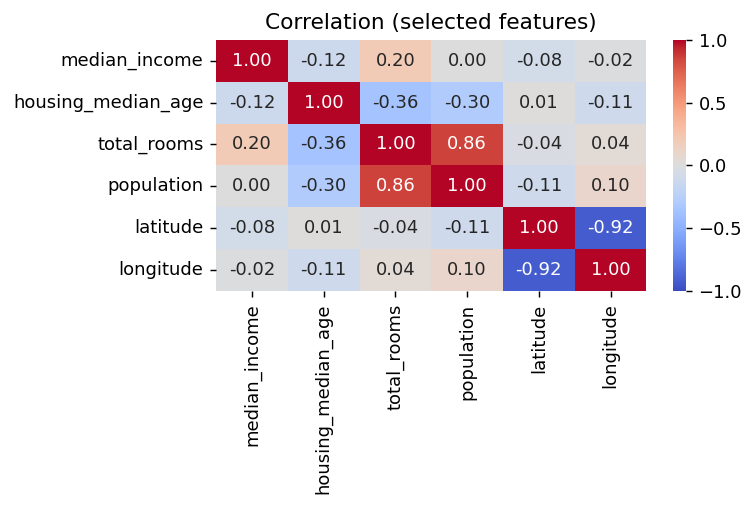

In [ ]:
selected_cat = ["median_income","housing_median_age","total_rooms","population","latitude","longitude"]
correlation = df[selected_cat].corr(method="pearson")
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1, cmap="coolwarm", fmt=".2f")
plt.title("Correlation (selected features)")
plt.tight_layout(); plt.show()


> ### Correlation Analysis  
>  
> The correlation matrix highlights several important relationships, for exmaple:  
>  
> - Total rooms and population are very strongly correlated (0.86), which suggests redundancy
> - Housing median age is moderately negatively correlated with total rooms (-0.36) and population (-0.30)
> - Latitude and longitude are strongly negatively correlated (-0.92), reflecting geographic positioning
> - Median income shows weaker correlations with other features, indicating it provides unique information
>  
> All these correlations shown above are significant  because PDP can be misleading when features are correlated. Although  ALE is more robust. The strong room–population link and geographic correlation emphasize why ALE will be an important check later

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


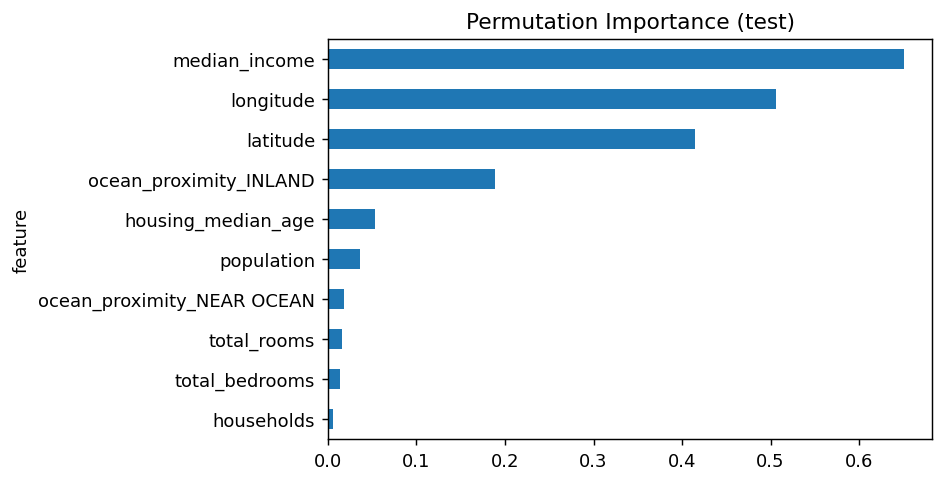

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp_df = (pd.DataFrame({"feature": X.columns,
                        "importance": r.importances_mean,
                        "std": r.importances_std})
          .sort_values("importance", ascending=False))
imp_df.head(10)
(imp_df.set_index("feature")["importance"].head(10)
      .plot(kind="barh", figsize=(6,4)))
plt.title("Permutation Importance (test)")
plt.gca().invert_yaxis()
plt.show()


> ### Permutation Importance  
>  
> Permutation importance on the test set shows that median income, longitude, and latitude are the strongest predictors of house values.  
> Ocean proximity (inland) also contributes meaningfully, while other features such as rooms, bedrooms, and households add little once correlations are considered.  
>  
> These results help prioritize which features to explore with PDP, ICE, and ALE. They also highlight that while correlated features like rooms and population exist, their predictive power is overshadowed by income and geography.  


## Partial Dependence Plot (PDP)

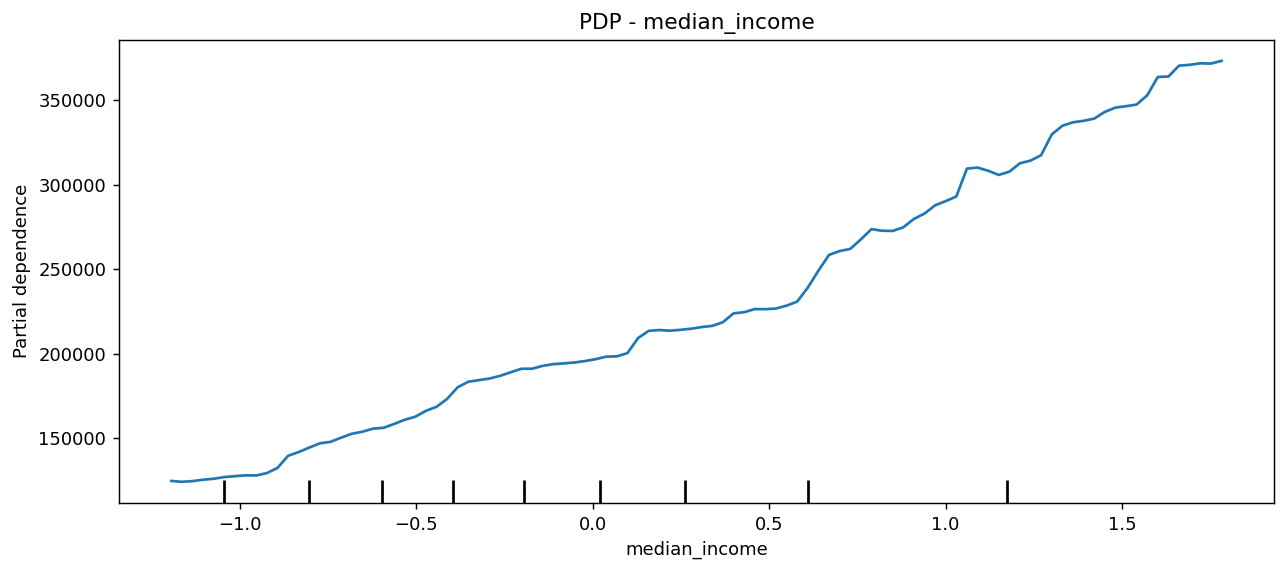

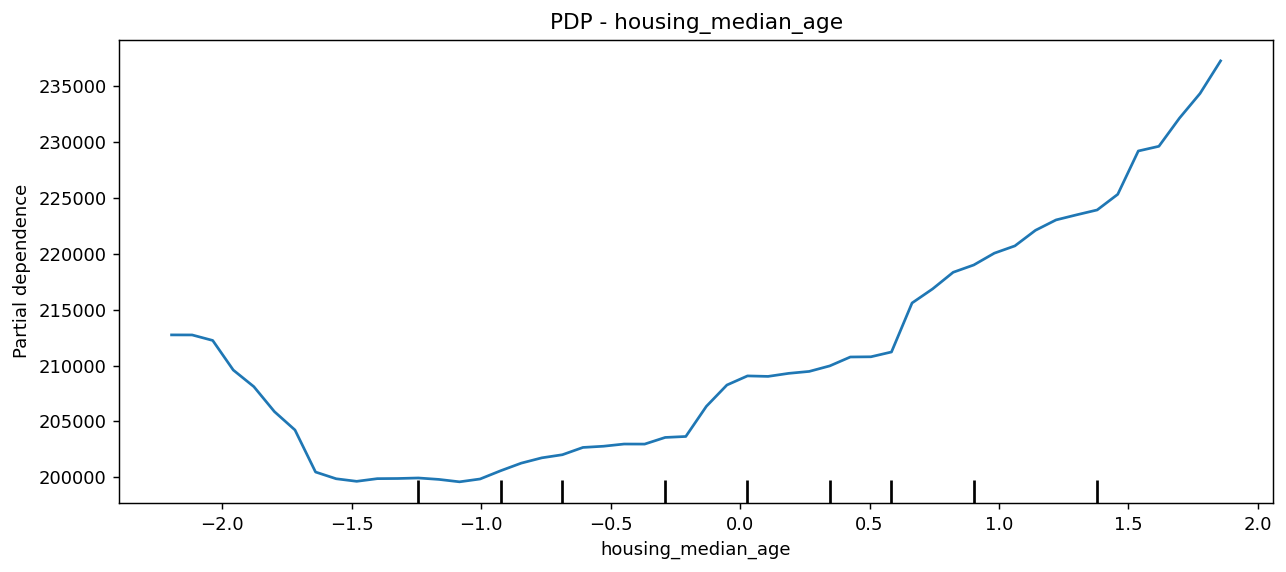

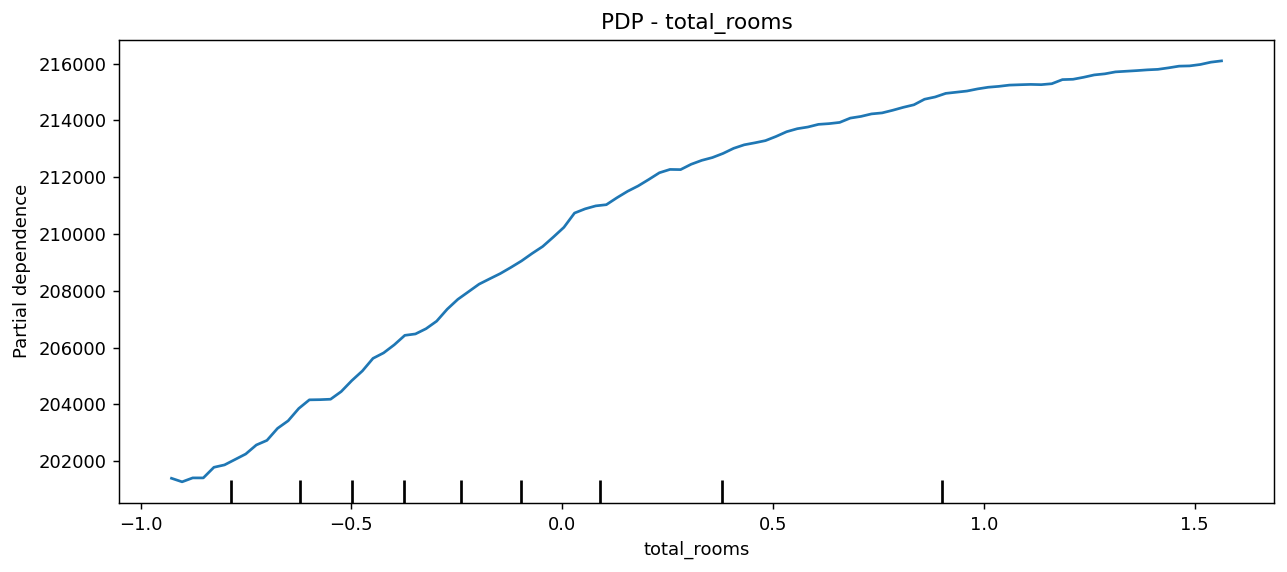

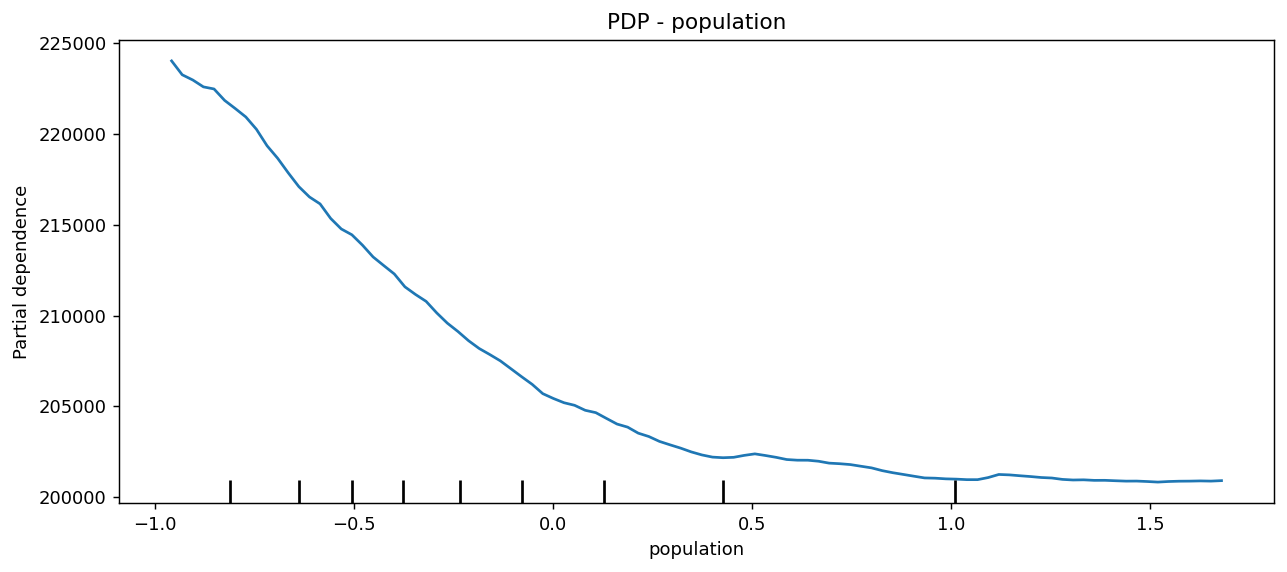

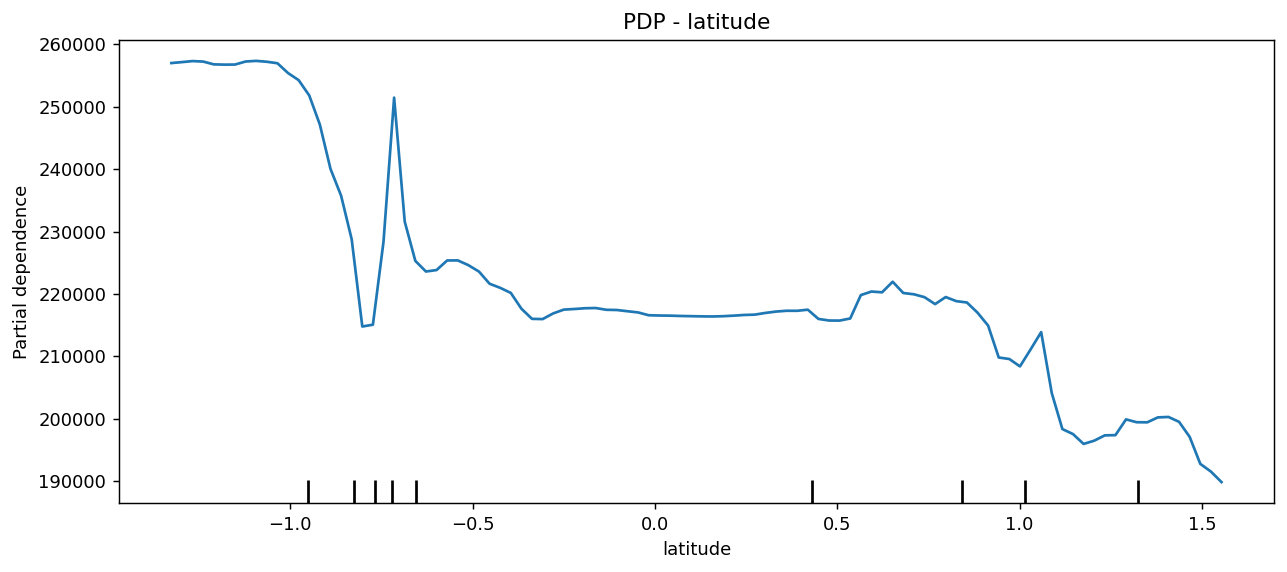

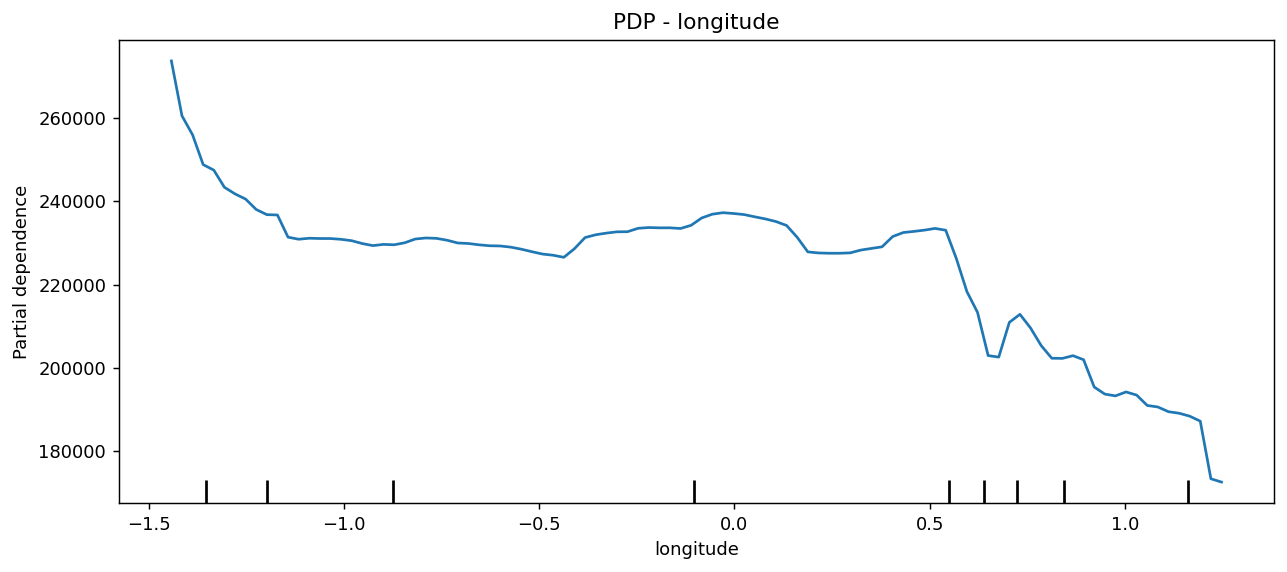

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# loop through features and plot PDP for each
for f in features_to_explain:
    PartialDependenceDisplay.from_estimator(
        rf,
        X_test,      # evaluation data
        [f],
        kind="average",
    )
    plt.title(f"PDP - {f}")
    plt.tight_layout()
    plt.show()

# Citation: The PDP plotting loop was clarified using ChatGPT on 09/28/25 at 4:55 PM.
# I was unsure whether to use the full dataset or the test split and ChatGPT recommended using X_test.


> ### PDP Interpretation  
> PDP shows the average change in prediction as one feature varies, holding others fixed.  
>  
> - **Median Income**  
>   - Pattern: Monotonic increase that plateaus at high values.  
>   - Effect: Strong positive.  
>   - Notes: Strongest predictor; wealthier tracts → higher predicted house values.  
>  
> - **Housing Median Age**  
>   - Pattern: Weak U-shape.  
>   - Effect: Mixed.  
>   - Notes: New and old areas predict slightly higher values, mid-aged areas lower. Reflects housing desirability cycles.  
>  
> - **Total Rooms**  
>   - Pattern: Mild upward slope.  
>   - Effect: Weak positive.  
>   - Notes: More rooms increase value, but effect is modest; correlation with density may influence results.  
>  
> - **Population**  
>   - Pattern: Steady downward slope.  
>   - Effect: Negative.  
>   - Notes: Higher tract populations predict lower values; aligns with inland crowding/lower desirability.  
>  
> - **Latitude**  
>   - Pattern: Declines northward.  
>   - Effect: Negative.  
>   - Notes: Northern CA predicts lower values; Southern CA and Bay Area predict higher values.  
>  
> - **Longitude**  
>   - Pattern: Declines moving inland (eastward).  
>   - Effect: Negative.  
>   - Notes: Clear coastal premium; houses near the Pacific predict higher values.  
>  
> **Summary**:  
> PDP results show that income and geography (latitude/longitude) dominate model predictions, while total rooms and population play secondary roles. Median income is strong and monotonic, while geographic features capture California’s coastal premium and regional variation.  
>  
> **Caution**:  
> PDP averages over other features and can evaluate unrealistic combinations when features are correlated (for example, very high total_rooms with very low households). This can blur true effects. ICE will reveal heterogeneity across observations and ALE will verify effects under correlation.  


## Individual Conditional Expectation (ICE)

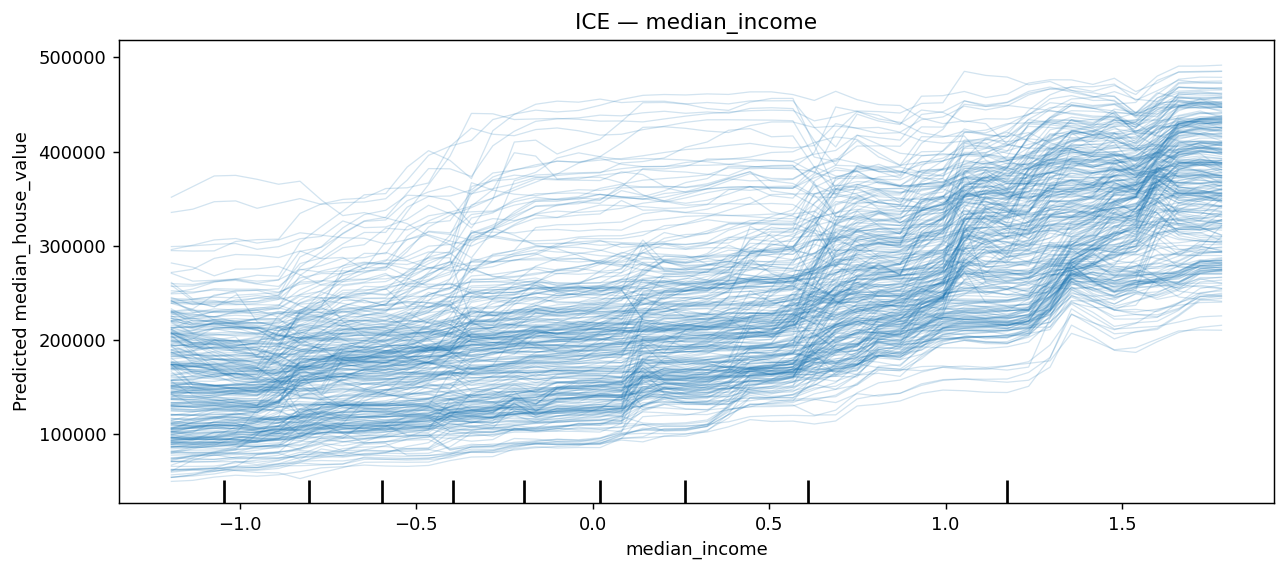

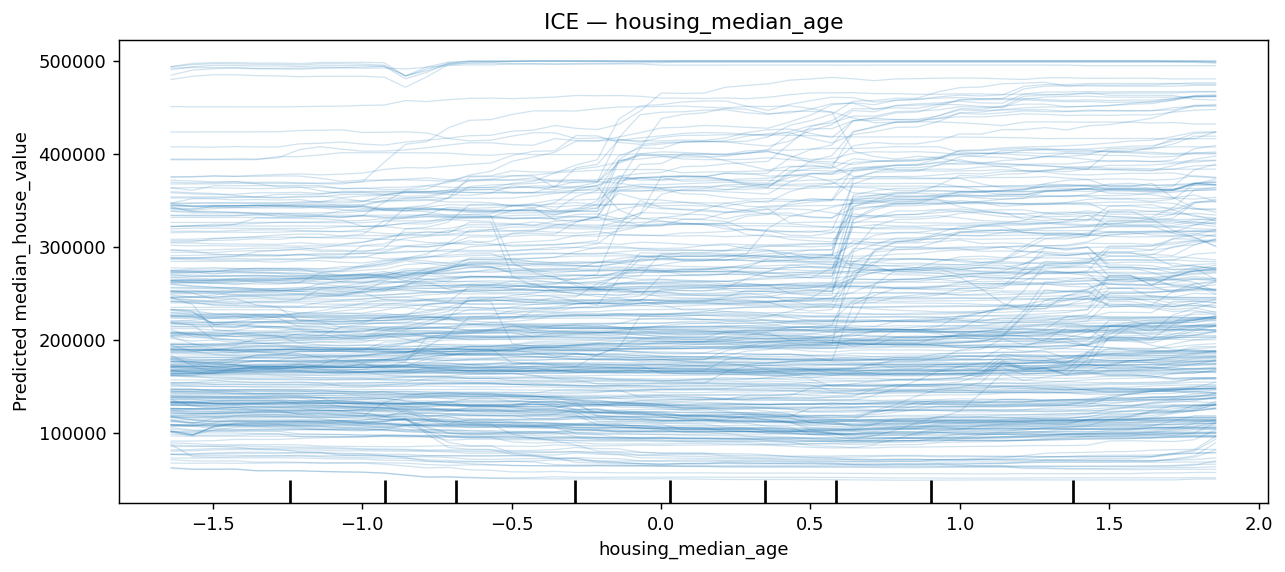

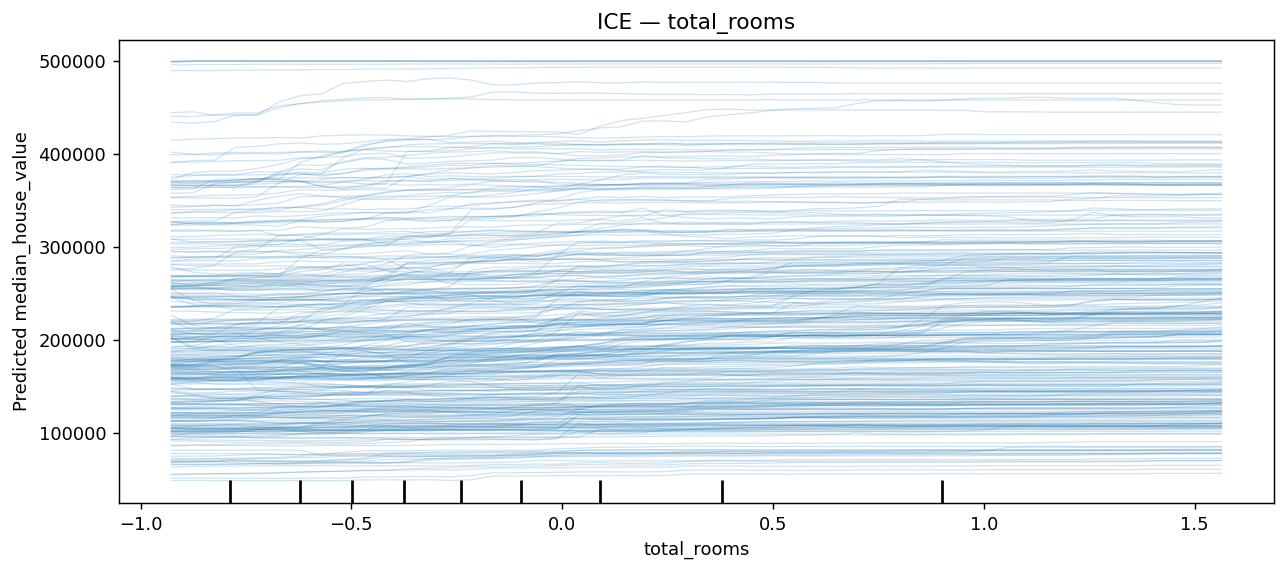

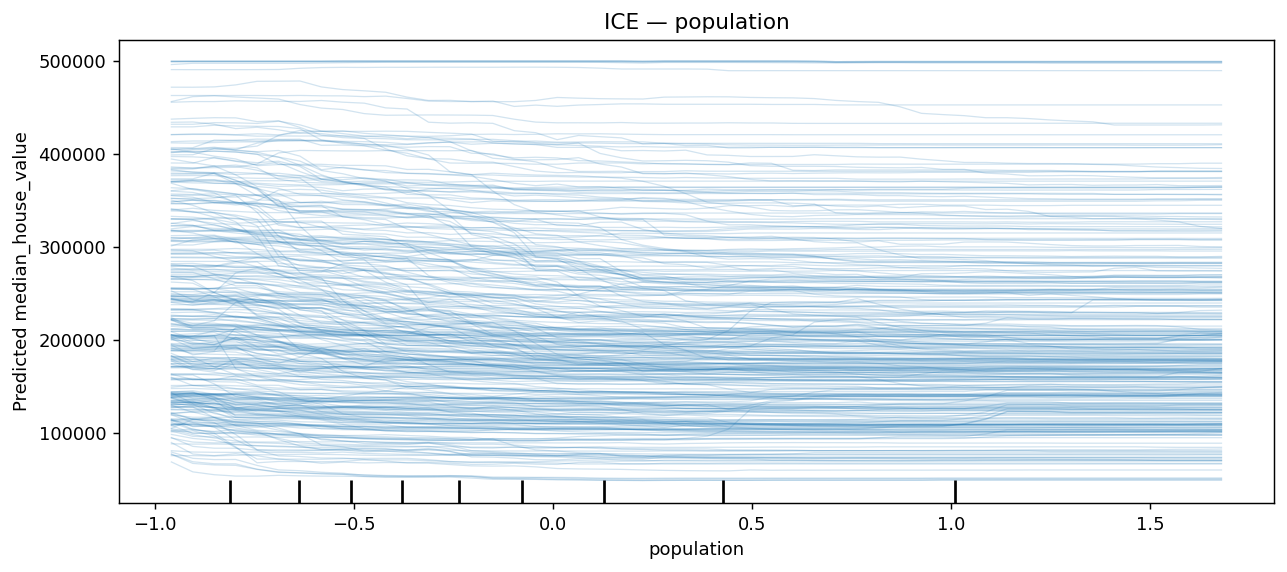

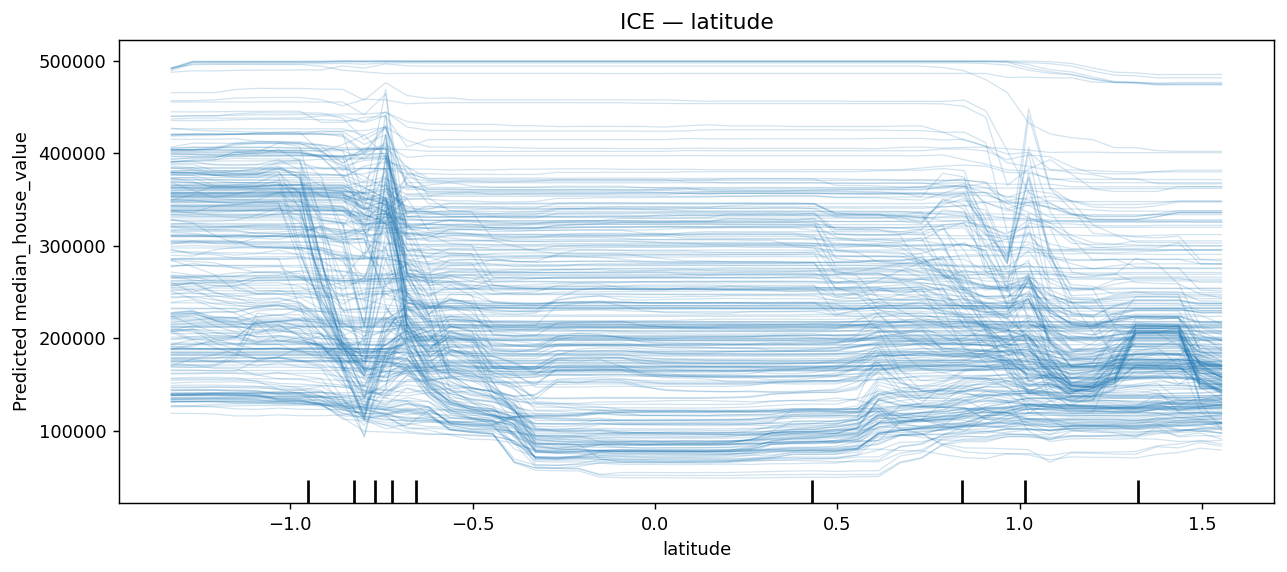

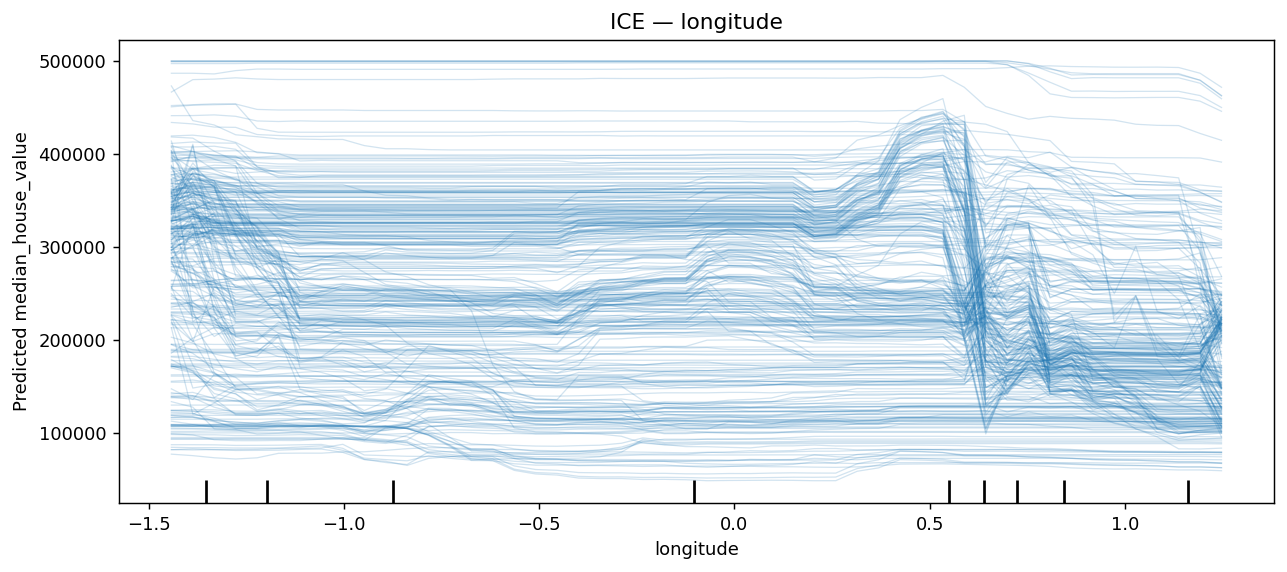

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
for f in features_to_explain:
    PartialDependenceDisplay.from_estimator(
        rf,
        X_test,
        [f],
        kind="individual",       # ICE only
        subsample=300,
        random_state=42,
        grid_resolution=50,
        ice_lines_kw={"alpha": 0.2, "linewidth": 0.7}
    )
    plt.title(f"ICE — {f}")
    plt.xlabel(f)
    plt.ylabel("Predicted median_house_value")
    plt.tight_layout()
    plt.show()

# ICE plots for each feature
# Citation: ChatGPT was used on 09/28/25 at 5:25 PM to help clarify this loop.
# It suggested using X_test instead of X, subsampling for readability, tried to retain dr.bent's code structure


> ### ICE Interpretation  
> ICE plots show how individual predictions change as a feature varies, holding others fixed. Unlike PDP, which shows the average, ICE reveals heterogeneity across tracts.  
>  
> - **Median Income**  
>   - Behavior: Lines mostly parallel, monotonic upward trend.  
>   - Notes: Strong, consistent effect across tracts; higher income → higher predicted house value.  
>  
> - **Housing Median Age**  
>   - Behavior: Lines nearly flat with small spread.  
>   - Notes: Weak effect once other features are considered; interactions are limited.  
>  
> - **Total Rooms**  
>   - Behavior: Nearly parallel with a weak slope.  
>   - Notes: More rooms slightly increase value, but the effect is modest and diluted by density.  
>  
> - **Population**  
>   - Behavior: Spread increases, with some crossings.  
>   - Notes: Denser tracts respond differently, suggesting interactions with geography and income.  
>  
> - **Latitude**  
>   - Behavior: Large spread, non-parallel lines.  
>   - Notes: Regional heterogeneity is clear — coastal south vs inland/north differences.  
>  
> - **Longitude**  
>   - Behavior: Wide spread, frequent crossings.  
>   - Notes: Strong geographic interactions; coastal premium vs inland discount.  
>  
> **Summary**: ICE highlights heterogeneity that PDP averages mask. Median income shows a stable, monotonic effect across tracts, while geographic features (latitude, longitude) exhibit strong interactions with other variables.  
>  
> **Caution**: ICE varies one feature at a time while holding others fixed, which may create unrealistic combinations when features are correlated. ALE plots (next) help validate which effects are robust under correlation.  


## Accumulated Local Effects (ALE)

In [ ]:
!pip install git+https://github.com/MaximeJumelle/ALEPython.git#egg=alepython

  Cloning https://github.com/MaximeJumelle/ALEPython.git to /tmp/pip-install-zib9gn7l/alepython_63cd8631f78b4da3977f5a477e3ad8e8
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-zib9gn7l/alepython_63cd8631f78b4da3977f5a477e3ad8e8
  Resolved https://github.com/MaximeJumelle/ALEPython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.3 MB/s eta 0:00:00
  Created wheel for alepython: filename=alepython-0.1.dev17+g286350ab6-py3-none-any.whl size=15251 sha256=f2ffc8ec8f731598bbf0ce100e73463e00a7733f565ceea6aa4d343ddd23ccad
  Stored in directory: /tmp/pip-ephem-wheel-cache-yjweej1q/wheels/ac/53/b0/a97d25e58a01046878d531f42b6dd5f19b185a0cefc6a4afbf
Successfully built alepython


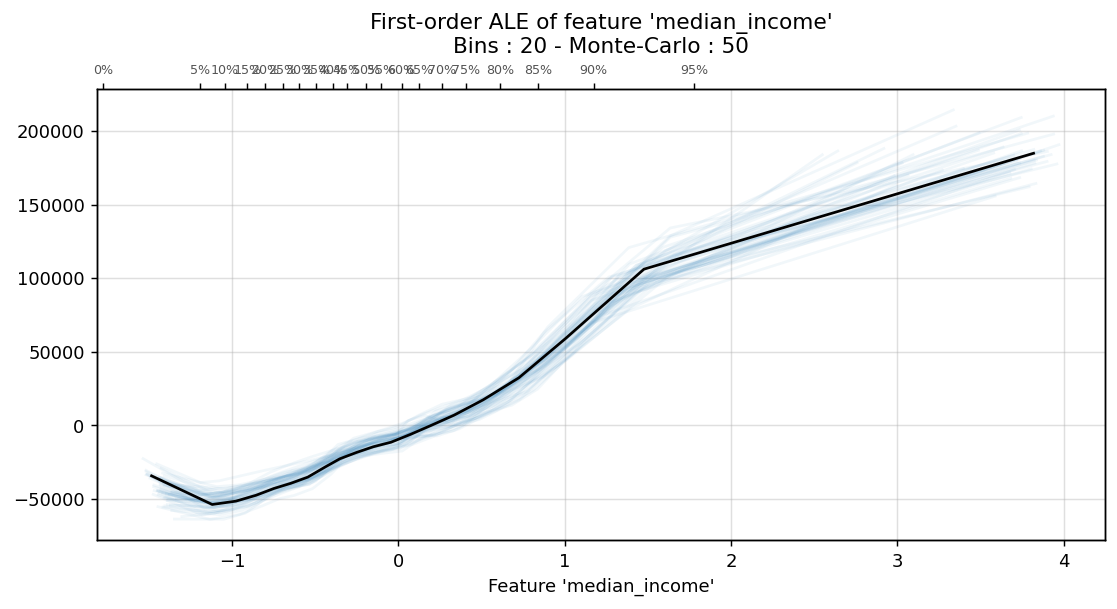

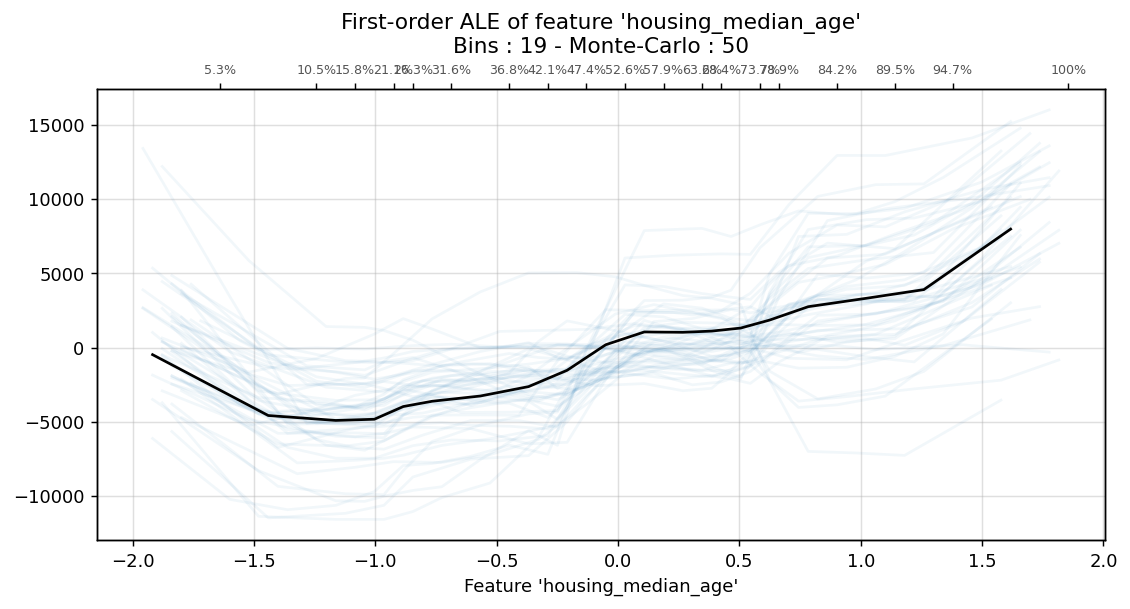

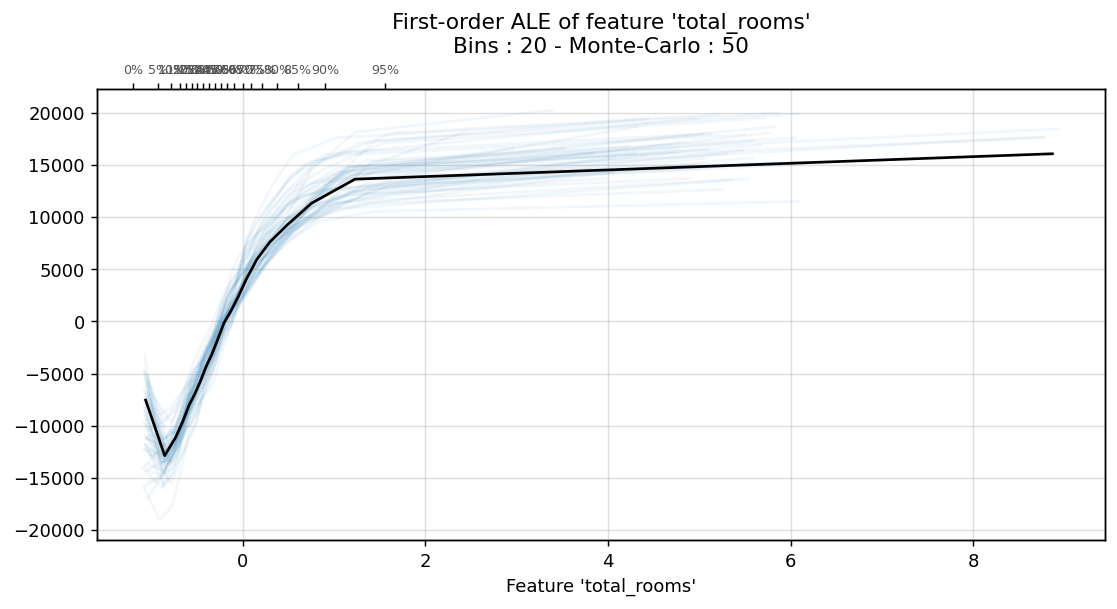

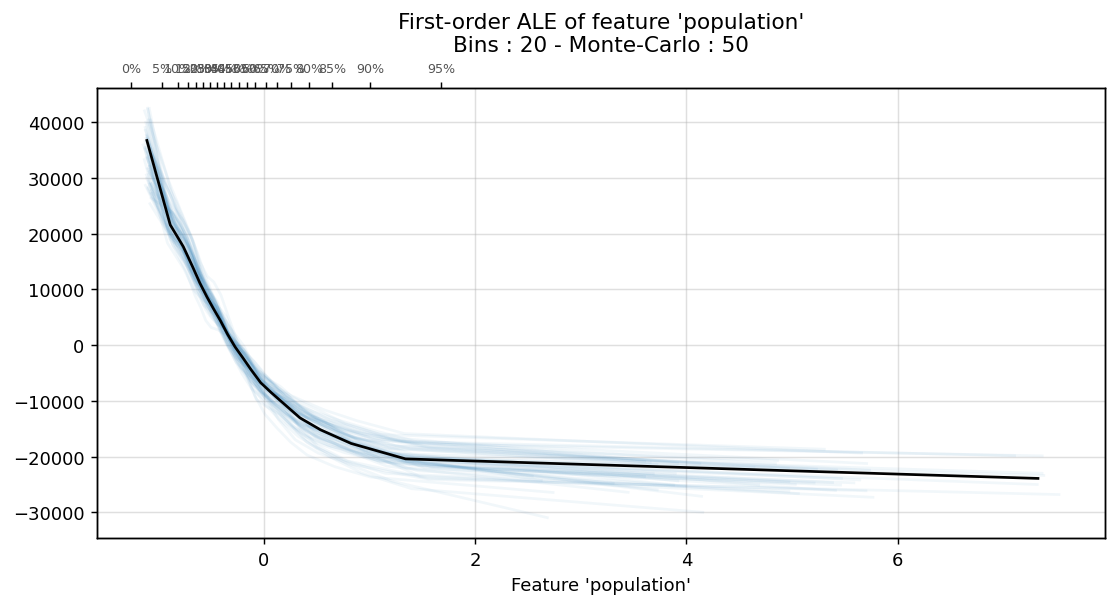

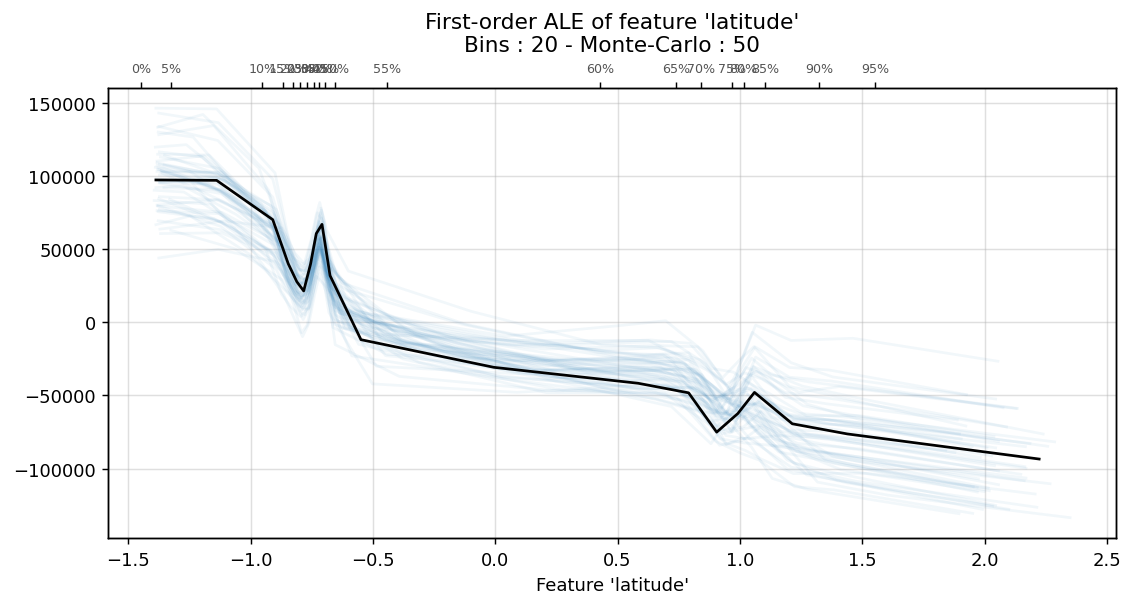

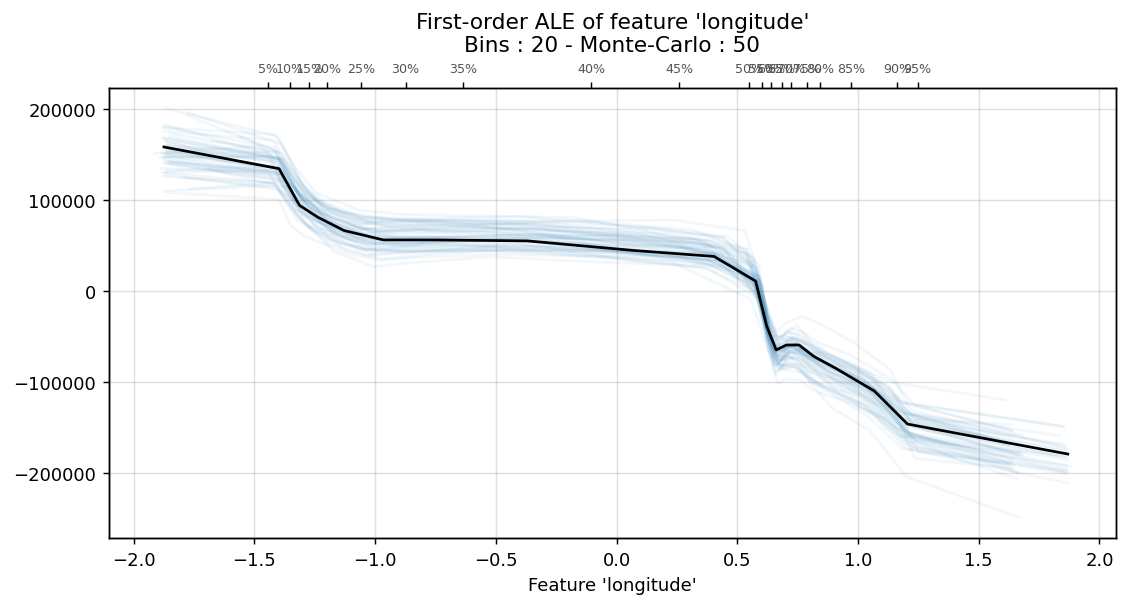

In [ ]:
# ALE plots for selected features
# Citation: Code structure and improvements (using ax.set_title, tight_layout, and plt.close to prevent blank figures) were refined with assistance from ChatGPT (OpenAI, 09/28/2025).

from alepython.ale import ale_plot

for f in features_to_explain:
    ax = ale_plot(rf, X_test, f, bins=20, monte_carlo=True)
    ax.set_title(f"ALE — {f}")
    ax.figure.tight_layout()
    plt.show()
    plt.close(ax.figure)


> ### ALE Interpretation  
> ALE plots show the average *local effect* of a feature on predictions, aggregated across bins. Unlike PDP, ALE corrects for feature correlations and centers effects, making it more robust and interpretable.  
>  
> - **Median Income**  
>   - Behavior: Strong, monotonic increase.  
>   - Notes: Dominant driver; higher income steadily raises predicted house values with diminishing returns.  
>  
> - **Housing Median Age**  
>   - Behavior: Weak, slightly upward trend.  
>   - Notes: Minimal effect overall; only a small positive slope at higher ages.  
>  
> - **Total Rooms**  
>   - Behavior: Sharp rise at low values, then plateau.  
>   - Notes: Shows diminishing returns; once room counts pass a threshold, additional rooms have little impact.  
>  
> - **Population**  
>   - Behavior: Steady negative effect that flattens.  
>   - Notes: Denser tracts predict lower values, but the impact levels off at higher populations.  
>  
> - **Latitude**  
>   - Behavior: Nonlinear with steep drops northward.  
>   - Notes: Captures geographic differences; inland/northern tracts predict lower values than coastal/southern tracts.  
>  
> - **Longitude**  
>   - Behavior: Consistent eastward decline.  
>   - Notes: Strong coastal premium; inland areas show large reductions in predicted values.  
>  
> **Summary**:  
> ALE confirms that income and geography dominate, while size and density play secondary roles and housing age is minor. Compared to PDP/ICE, ALE provides cleaner, correlation-robust estimates of feature effects.  
>  
> **Caution**:  
> ALE depends on binning choices (20 bins here). Too few bins oversmooth, too many add noise. While ALE reduces correlation bias, it does not eliminate it entirely.  

## Overall Findings  

### PDP vs ICE vs ALE — Differences and Correlation Impact  

- **PDP**: Shows the global average effect of a feature but can be biased when features are correlated.  
- **ICE**: Breaks PDP into individual lines, revealing heterogeneity across tracts. It shows whether the average trend in PDP is consistent across all instances or masks subgroup differences.  
- **ALE**: Adjusts for correlation, computing local differences and centering them. This provides more robust estimates, especially for correlated features.  

### Feature-Level Comparisons  

- **Median Income**  
  - PDP and ALE both show a strong monotonic increase.  
  - ICE confirms the effect is consistent across tracts (nearly parallel lines).  

- **Housing Median Age**  
  - PDP and ALE show weak, flat effects.  
  - ICE reveals limited heterogeneity, reinforcing that age is not a strong driver.  

- **Total Rooms**  
  - PDP suggests a smoother positive slope.  
  - ICE shows some variation across tracts.  
  - ALE reveals the most realistic picture: a sharp rise at low values with diminishing returns, correcting for correlation with population.  

- **Population**  
  - PDP implies a strong negative effect.  
  - ICE shows heterogeneity (different tracts respond differently).  
  - ALE moderates the effect, showing it flattens at higher values — correcting for correlation with room count and density.  

- **Latitude & Longitude**  
  - PDP highlights strong geographic effects.  
  - ICE shows wide heterogeneity (lines crossing, non-parallel).  
  - ALE smooths these into robust nonlinear curves, capturing regional patterns without overstatement.  

### Exploratory Findings on Correlation  

Correlation analysis showed strong links between `total_rooms`, `population`, and `households`, as well as regional structure in latitude/longitude. These correlations explain why:  
- PDP may exaggerate effects.  
- ICE exposes variability across tracts.  
- ALE provides the most stable interpretation.  


### Takeaway  

- **PDP**: Intuitive but correlation-prone.  
- **ICE**: Reveals heterogeneity and subgroup differences.  
- **ALE**: Most robust under correlation, providing centered local effects.  

Together, these plots confirm that **income and geography dominate**, while room count and population effects weaken once correlations are accounted for.